In [1]:
# ============================================================================
# TASK 5: STRATEGY BACKTESTING
# ============================================================================
# Business Objective:
# Validate our model-driven portfolio strategy against a passive benchmark
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [2]:
# ============================================================================
# STEP 2: LOAD DATA AND DEFINE BACKTESTING PERIOD
# ============================================================================

print("=" * 70)
print("📊 LOADING DATA AND DEFINING BACKTESTING PERIOD")
print("=" * 70)

# Load cleaned data
adj_close_df = pd.read_csv('../data/processed/adj_close_data_clean.csv', 
                           index_col=0, parse_dates=True)

# Calculate daily returns
returns_df = adj_close_df.pct_change().dropna()

print(f"Data shape: {adj_close_df.shape}")
print(f"Date range: {adj_close_df.index.min()} to {adj_close_df.index.max()}")
print(f"Assets: {adj_close_df.columns.tolist()}")

# Define backtesting period (last year of data)
# This should be data NOT used for training models
backtest_end = adj_close_df.index[-1]
backtest_start = backtest_end - timedelta(days=365)

# Find the closest trading days
backtest_start = adj_close_df.index[adj_close_df.index >= backtest_start][0]
backtest_end = adj_close_df.index[-1]

# Get data for backtesting period
backtest_prices = adj_close_df.loc[backtest_start:backtest_end]
backtest_returns = returns_df.loc[backtest_start:backtest_end]

print("\n📊 Backtesting Period:")
print(f"  Start: {backtest_start.strftime('%Y-%m-%d')}")
print(f"  End: {backtest_end.strftime('%Y-%m-%d')}")
print(f"  Total trading days: {len(backtest_prices)}")

# Display first and last prices
print("\n📊 Backtesting Data:")
print(f"  TSLA: ${backtest_prices['TSLA'].iloc[0]:.2f} → ${backtest_prices['TSLA'].iloc[-1]:.2f}")
print(f"  BND:  ${backtest_prices['BND'].iloc[0]:.2f} → ${backtest_prices['BND'].iloc[-1]:.2f}")
print(f"  SPY:  ${backtest_prices['SPY'].iloc[0]:.2f} → ${backtest_prices['SPY'].iloc[-1]:.2f}")


📊 LOADING DATA AND DEFINING BACKTESTING PERIOD
Data shape: (2888, 3)
Date range: 2015-01-02 00:00:00 to 2026-06-29 00:00:00
Assets: ['TSLA', 'BND', 'SPY']

📊 Backtesting Period:
  Start: 2025-06-30
  End: 2026-06-29
  Total trading days: 251

📊 Backtesting Data:
  TSLA: $317.66 → $411.84
  BND:  $70.80 → $73.47
  SPY:  $611.08 → $741.00


In [3]:
# ============================================================================
# STEP 3: DEFINE BENCHMARK PORTFOLIO
# ============================================================================
# Business Context:
# A common benchmark is a balanced 60/40 portfolio
# This represents a simple passive strategy we compare against
# ============================================================================

print("\n" + "=" * 70)
print("📊 DEFINING BENCHMARK PORTFOLIO")
print("=" * 70)

# Benchmark weights: 60% SPY, 40% BND
benchmark_weights = {
    'TSLA': 0.0,  # No Tesla in benchmark
    'BND': 0.40,  # 40% bonds
    'SPY': 0.60   # 60% S&P 500
}

print("\n📊 Benchmark Portfolio (60/40):")
print(f"  BND:  {benchmark_weights['BND']*100:.0f}%")
print(f"  SPY:  {benchmark_weights['SPY']*100:.0f}%")
print(f"  TSLA: {benchmark_weights['TSLA']*100:.0f}%")
print("\nThis is a common passive strategy - it simply holds 60% stocks and 40% bonds.")


📊 DEFINING BENCHMARK PORTFOLIO

📊 Benchmark Portfolio (60/40):
  BND:  40%
  SPY:  60%
  TSLA: 0%

This is a common passive strategy - it simply holds 60% stocks and 40% bonds.


In [4]:
# ============================================================================
# STEP 4: DEFINE OUR STRATEGY PORTFOLIO
# ============================================================================
# Business Context:
# We use the optimal weights from Task 4 (Maximum Sharpe Ratio portfolio)
# This represents our model-driven strategy
# ============================================================================

print("\n" + "=" * 70)
print("📊 DEFINING STRATEGY PORTFOLIO")
print("=" * 70)

# Load the optimal weights from Task 4
try:
    recommendation_df = pd.read_csv('../data/processed/portfolio_recommendation.csv')
    strategy_weights = {}
    for _, row in recommendation_df.iterrows():
        strategy_weights[row['Asset']] = row['Weight (%)'] / 100
    print("✅ Loaded optimal weights from Task 4")
except:
    # Fallback: use weights from Task 4 output
    # You should replace these with your actual optimal weights
    strategy_weights = {
        'TSLA': 0.60,  # Replace with your actual TSLA weight
        'BND': 0.20,   # Replace with your actual BND weight
        'SPY': 0.20    # Replace with your actual SPY weight
    }
    print("⚠️ Using fallback weights. Please update with your actual optimal weights.")

print("\n📊 Strategy Portfolio (from Task 4):")
for asset, weight in strategy_weights.items():
    print(f"  {asset}: {weight*100:.1f}%")

# Check if weights sum to 1
total_weight = sum(strategy_weights.values())
if abs(total_weight - 1.0) > 0.01:
    print(f"\n⚠️ Warning: Weights sum to {total_weight:.2f}. Normalizing...")
    for asset in strategy_weights:
        strategy_weights[asset] = strategy_weights[asset] / total_weight


📊 DEFINING STRATEGY PORTFOLIO
✅ Loaded optimal weights from Task 4

📊 Strategy Portfolio (from Task 4):
  TSLA: 0.0%
  BND: 30.8%
  SPY: 69.2%


In [5]:
# ============================================================================
# STEP 5: SIMULATE PORTFOLIO PERFORMANCE
# ============================================================================
# Business Context:
# We simulate both strategies on historical data to compare performance
# This shows what would have happened if we used each strategy
# ============================================================================

print("\n" + "=" * 70)
print("🔄 SIMULATING PORTFOLIO PERFORMANCE")
print("=" * 70)

# Function to calculate portfolio returns
def calculate_portfolio_returns(weights, returns_df):
    """
    Calculate portfolio returns given weights and asset returns.
    
    Parameters:
    - weights: Dictionary of asset weights
    - returns_df: DataFrame of asset returns
    
    Returns:
    - portfolio_returns: Series of portfolio daily returns
    """
    # Create array of weights in same order as returns_df columns
    weight_array = np.array([weights.get(asset, 0) for asset in returns_df.columns])
    
    # Calculate portfolio returns
    portfolio_returns = returns_df.dot(weight_array)
    
    return portfolio_returns

# Calculate benchmark returns
benchmark_returns = calculate_portfolio_returns(benchmark_weights, backtest_returns)

# Calculate strategy returns
strategy_returns = calculate_portfolio_returns(strategy_weights, backtest_returns)

print("✅ Portfolio returns calculated!")

# Calculate cumulative returns
benchmark_cumulative = (1 + benchmark_returns).cumprod()
strategy_cumulative = (1 + strategy_returns).cumprod()

print(f"\n📊 Cumulative Returns:")
print(f"  Benchmark: {benchmark_cumulative.iloc[-1]:.2%}")
print(f"  Strategy:  {strategy_cumulative.iloc[-1]:.2%}")


🔄 SIMULATING PORTFOLIO PERFORMANCE
✅ Portfolio returns calculated!

📊 Cumulative Returns:
  Benchmark: 114.64%
  Strategy:  116.27%


In [6]:
# ============================================================================
# STEP 6: MONTHLY REBALANCING (Advanced)
# ============================================================================
# Business Context:
# In real life, we would rebalance the portfolio periodically
# This maintains our target weights and captures gains
# ============================================================================

print("\n" + "=" * 70)
print("🔄 MONTHLY REBALANCING")
print("=" * 70)

def calculate_portfolio_with_rebalancing(weights, returns_df, rebalance_freq='M'):
    """
    Calculate portfolio returns with monthly rebalancing.
    
    Parameters:
    - weights: Dictionary of target weights
    - returns_df: DataFrame of asset returns
    - rebalance_freq: Frequency of rebalancing ('M' for month)
    
    Returns:
    - portfolio_returns: Series of portfolio daily returns
    """
    # Create weight array in same order as returns_df columns
    weight_array = np.array([weights.get(asset, 0) for asset in returns_df.columns])
    
    # Initialize portfolio returns
    portfolio_returns = pd.Series(index=returns_df.index, dtype=float)
    
    # Create a month identifier for grouping
    month_group = returns_df.index.to_period('M')
    
    # Group by month for rebalancing
    for month, group in returns_df.groupby(month_group):
        # Calculate returns for this period using the weights
        # For monthly rebalancing, we use the same weights for the entire month
        period_returns = group.dot(weight_array)
        portfolio_returns.loc[group.index] = period_returns
    
    return portfolio_returns

# Calculate strategy with monthly rebalancing
strategy_rebalanced_returns = calculate_portfolio_with_rebalancing(
    strategy_weights, backtest_returns, 'M'
)
strategy_rebalanced_cumulative = (1 + strategy_rebalanced_returns).cumprod()

print("✅ Monthly rebalancing calculated!")

# Compare with simple (no rebalancing)
print(f"\n📊 Final Cumulative Returns:")
print(f"  Benchmark: {benchmark_cumulative.iloc[-1]:.2%}")
print(f"  Strategy (no rebalancing): {strategy_cumulative.iloc[-1]:.2%}")
print(f"  Strategy (monthly rebalancing): {strategy_rebalanced_cumulative.iloc[-1]:.2%}")


🔄 MONTHLY REBALANCING
✅ Monthly rebalancing calculated!

📊 Final Cumulative Returns:
  Benchmark: 114.64%
  Strategy (no rebalancing): 116.27%
  Strategy (monthly rebalancing): 116.27%



📈 VISUALIZING PERFORMANCE


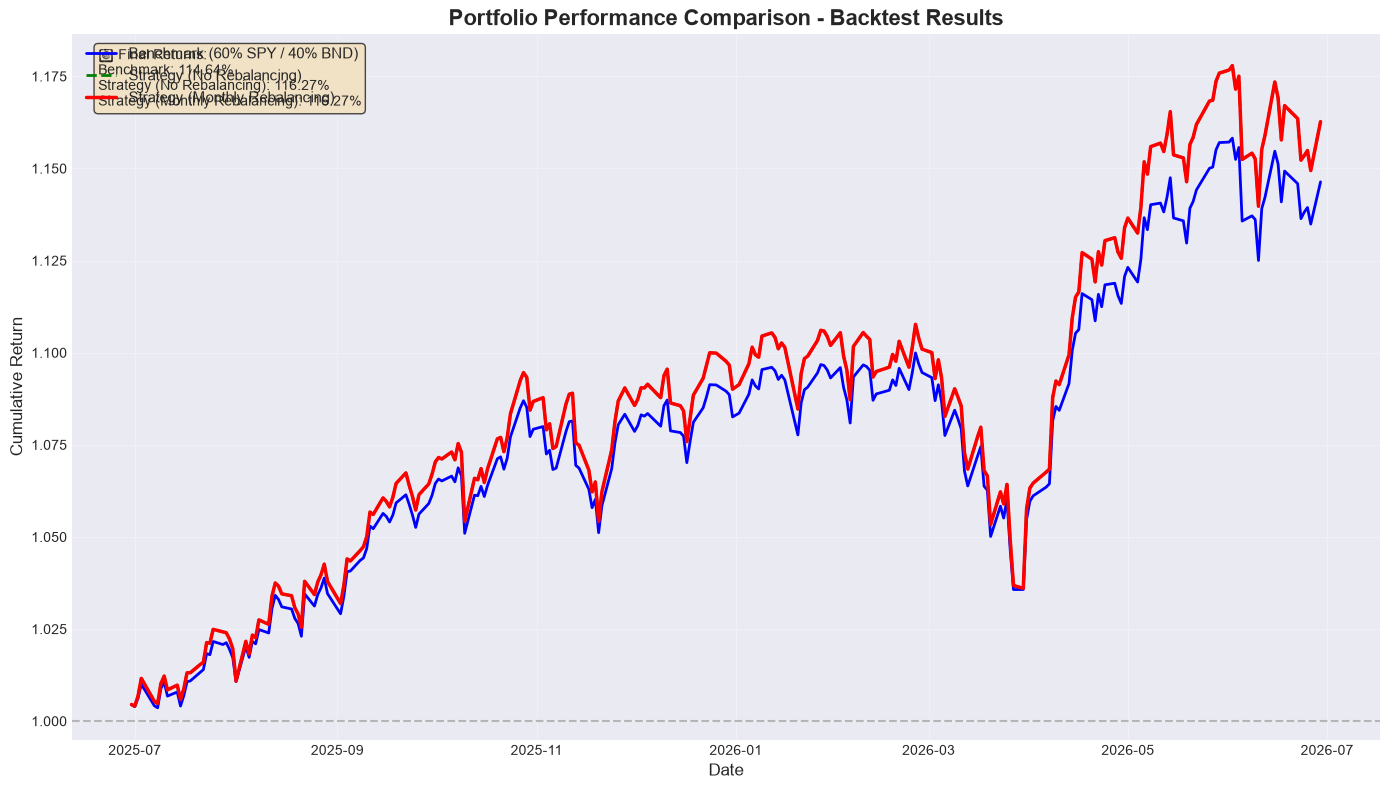

✅ Backtest visualization saved!


In [7]:
# ============================================================================
# STEP 7: VISUALIZE CUMULATIVE RETURNS
# ============================================================================

print("\n" + "=" * 70)
print("📈 VISUALIZING PERFORMANCE")
print("=" * 70)

# Create the plot
fig, ax = plt.subplots(figsize=(14, 8))

# 1. Plot Benchmark
ax.plot(benchmark_cumulative.index, benchmark_cumulative, 
        label='Benchmark (60% SPY / 40% BND)', 
        color='blue', linewidth=2)

# 2. Plot Strategy (no rebalancing)
ax.plot(strategy_cumulative.index, strategy_cumulative, 
        label='Strategy (No Rebalancing)', 
        color='green', linewidth=2, linestyle='--')

# 3. Plot Strategy (with rebalancing)
ax.plot(strategy_rebalanced_cumulative.index, strategy_rebalanced_cumulative, 
        label='Strategy (Monthly Rebalancing)', 
        color='red', linewidth=2.5)

# 4. Customize the plot
ax.set_title('Portfolio Performance Comparison - Backtest Results', 
             fontsize=16, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Cumulative Return', fontsize=12)
ax.legend(loc='upper left', fontsize=11)
ax.grid(True, alpha=0.3)

# Add horizontal line at 1.0 (starting point)
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)

# Add annotation with final returns
ax.text(0.02, 0.98, 
        f'📊 Final Returns:\n'
        f'Benchmark: {benchmark_cumulative.iloc[-1]:.2%}\n'
        f'Strategy (No Rebalancing): {strategy_cumulative.iloc[-1]:.2%}\n'
        f'Strategy (Monthly Rebalancing): {strategy_rebalanced_cumulative.iloc[-1]:.2%}',
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

plt.tight_layout()
plt.savefig('../data/processed/backtest_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Backtest visualization saved!")

In [8]:
# ============================================================================
# STEP 8: CALCULATE PERFORMANCE METRICS
# ============================================================================

print("\n" + "=" * 70)
print("📊 PERFORMANCE METRICS")
print("=" * 70)

def calculate_metrics(cumulative_returns, returns_series, name):
    """
    Calculate key performance metrics for a portfolio.
    """
    # Total return
    total_return = cumulative_returns.iloc[-1] - 1
    
    # Annualized return (assuming 252 trading days)
    days = len(returns_series)
    annualized_return = (1 + total_return) ** (252 / days) - 1
    
    # Annualized volatility
    annualized_volatility = returns_series.std() * (252 ** 0.5)
    
    # Sharpe ratio (risk-free rate = 1%)
    risk_free_rate = 0.01
    sharpe_ratio = (annualized_return - risk_free_rate) / annualized_volatility
    
    # Maximum drawdown
    rolling_max = cumulative_returns.expanding().max()
    drawdown = (cumulative_returns / rolling_max) - 1
    max_drawdown = drawdown.min()
    
    # Win rate
    win_rate = (returns_series > 0).sum() / len(returns_series)
    
    return {
        'Portfolio': name,
        'Total Return': total_return,
        'Annualized Return': annualized_return,
        'Annualized Volatility': annualized_volatility,
        'Sharpe Ratio': sharpe_ratio,
        'Max Drawdown': max_drawdown,
        'Win Rate': win_rate,
        'Days': len(returns_series)
    }

# Calculate metrics for each portfolio
metrics_list = []

# Benchmark
metrics_list.append(calculate_metrics(
    benchmark_cumulative, benchmark_returns, 'Benchmark (60/40)'
))

# Strategy (no rebalancing)
metrics_list.append(calculate_metrics(
    strategy_cumulative, strategy_returns, 'Strategy (No Rebalancing)'
))

# Strategy (monthly rebalancing)
metrics_list.append(calculate_metrics(
    strategy_rebalanced_cumulative, strategy_rebalanced_returns, 'Strategy (Monthly Rebalancing)'
))

# Create metrics DataFrame
metrics_df = pd.DataFrame(metrics_list)

# Format for display
display_df = metrics_df.copy()
display_df['Total Return'] = display_df['Total Return'].apply(lambda x: f"{x:.2%}")
display_df['Annualized Return'] = display_df['Annualized Return'].apply(lambda x: f"{x:.2%}")
display_df['Annualized Volatility'] = display_df['Annualized Volatility'].apply(lambda x: f"{x:.2%}")
display_df['Sharpe Ratio'] = display_df['Sharpe Ratio'].apply(lambda x: f"{x:.3f}")
display_df['Max Drawdown'] = display_df['Max Drawdown'].apply(lambda x: f"{x:.2%}")
display_df['Win Rate'] = display_df['Win Rate'].apply(lambda x: f"{x:.2%}")

print("\n📊 Performance Metrics Comparison:")
print("=" * 80)
print(display_df[['Portfolio', 'Total Return', 'Annualized Return', 
                  'Annualized Volatility', 'Sharpe Ratio', 'Max Drawdown', 'Win Rate']].to_string(index=False))

# Save metrics to CSV
metrics_df.to_csv('../data/processed/backtest_metrics.csv', index=False)
print("\n✅ Metrics saved to: data/processed/backtest_metrics.csv")


📊 PERFORMANCE METRICS

📊 Performance Metrics Comparison:
                     Portfolio Total Return Annualized Return Annualized Volatility Sharpe Ratio Max Drawdown Win Rate
             Benchmark (60/40)       14.64%            14.70%                 8.11%        1.689       -5.84%   56.18%
     Strategy (No Rebalancing)       16.27%            16.34%                 9.10%        1.686       -6.47%   54.98%
Strategy (Monthly Rebalancing)       16.27%            16.34%                 9.10%        1.686       -6.47%   54.98%

✅ Metrics saved to: data/processed/backtest_metrics.csv



📊 MONTHLY PERFORMANCE ANALYSIS

📊 Monthly Performance:
  Total months: 13
  Months strategy outperformed: 9
  Monthly win rate: 69.23%

📈 Best Month: 2026-04
  Strategy: 7.22%
  Benchmark: 6.26%

📉 Worst Month: 2026-03
  Strategy: -3.94%
  Benchmark: -3.65%


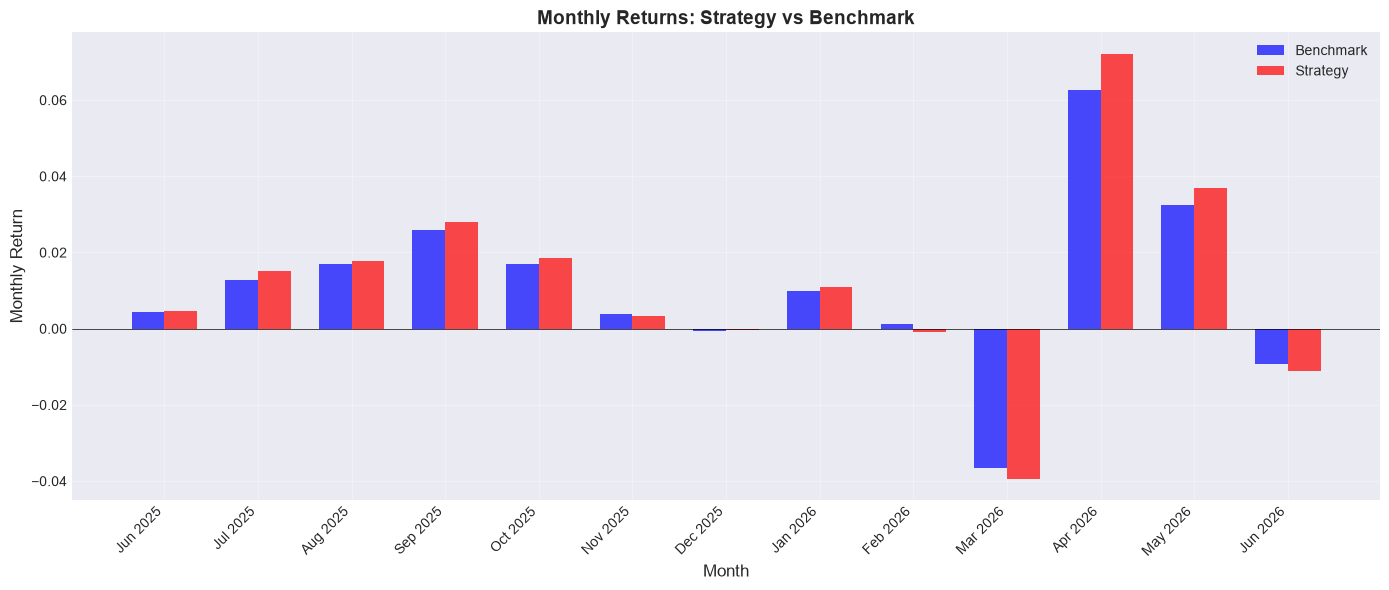

✅ Monthly comparison visualization saved!


In [10]:
# ============================================================================
# STEP 9: MONTHLY PERFORMANCE ANALYSIS
# ============================================================================

print("\n" + "=" * 70)
print("📊 MONTHLY PERFORMANCE ANALYSIS")
print("=" * 70)

# Calculate monthly returns - resample uses 'ME' (Month End)
benchmark_monthly = benchmark_returns.resample('ME').apply(lambda x: (1 + x).prod() - 1)
strategy_monthly = strategy_rebalanced_returns.resample('ME').apply(lambda x: (1 + x).prod() - 1)

# Create comparison DataFrame
monthly_comparison = pd.DataFrame({
    'Benchmark': benchmark_monthly,
    'Strategy': strategy_monthly
})

# Calculate which performed better each month
monthly_comparison['Strategy Better'] = monthly_comparison['Strategy'] > monthly_comparison['Benchmark']
strategy_wins = monthly_comparison['Strategy Better'].sum()
total_months = len(monthly_comparison)
win_rate_monthly = strategy_wins / total_months if total_months > 0 else 0

print(f"\n📊 Monthly Performance:")
print(f"  Total months: {total_months}")
print(f"  Months strategy outperformed: {strategy_wins}")
print(f"  Monthly win rate: {win_rate_monthly:.2%}")

# Best and worst months (if data exists)
if len(monthly_comparison) > 0:
    best_month = monthly_comparison.loc[monthly_comparison['Strategy'].idxmax()]
    worst_month = monthly_comparison.loc[monthly_comparison['Strategy'].idxmin()]

    print(f"\n📈 Best Month: {best_month.name.strftime('%Y-%m')}")
    print(f"  Strategy: {best_month['Strategy']:.2%}")
    print(f"  Benchmark: {best_month['Benchmark']:.2%}")

    print(f"\n📉 Worst Month: {worst_month.name.strftime('%Y-%m')}")
    print(f"  Strategy: {worst_month['Strategy']:.2%}")
    print(f"  Benchmark: {worst_month['Benchmark']:.2%}")

# Visualize monthly comparison
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(monthly_comparison))
width = 0.35

ax.bar(x - width/2, monthly_comparison['Benchmark'], width, label='Benchmark', color='blue', alpha=0.7)
ax.bar(x + width/2, monthly_comparison['Strategy'], width, label='Strategy', color='red', alpha=0.7)

ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Monthly Return', fontsize=12)
ax.set_title('Monthly Returns: Strategy vs Benchmark', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(monthly_comparison.index.strftime('%b %Y'), rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/processed/backtest_monthly_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Monthly comparison visualization saved!")


📊 MONTHLY PERFORMANCE ANALYSIS

📊 Monthly Performance:
  Total months: 13
  Months strategy outperformed: 9
  Monthly win rate: 69.23%

📈 Best Month: 2026-04
  Strategy: 7.22%
  Benchmark: 6.26%

📉 Worst Month: 2026-03
  Strategy: -3.94%
  Benchmark: -3.65%


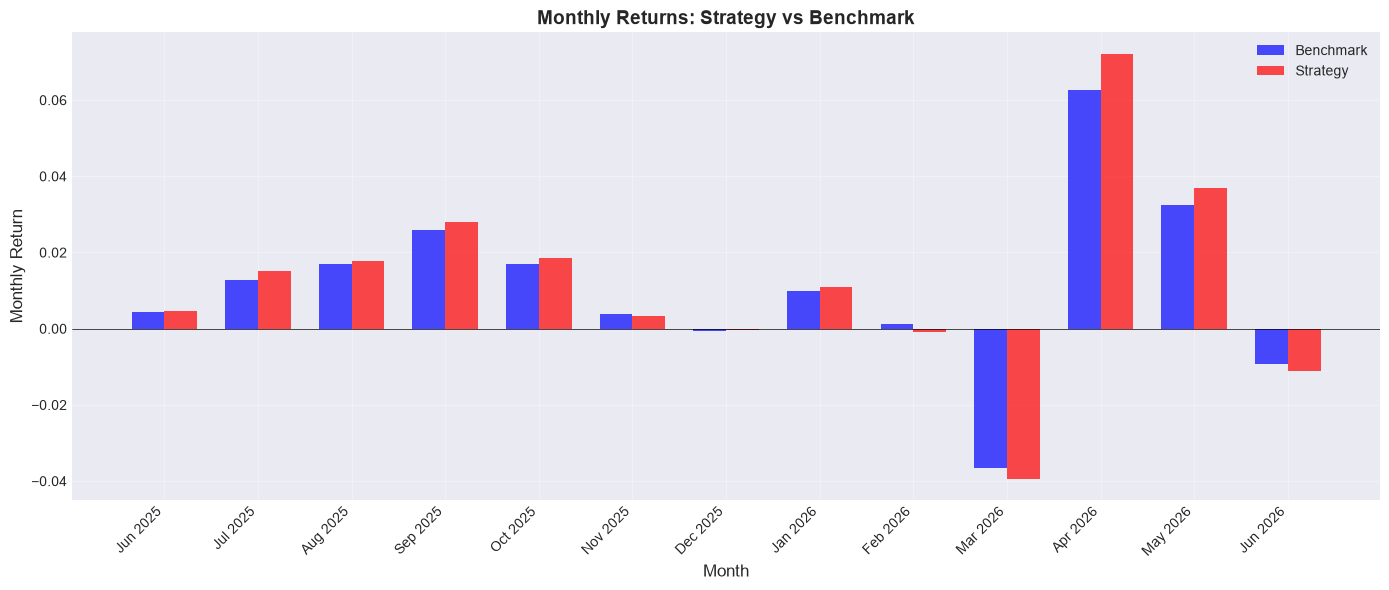

✅ Monthly comparison visualization saved!


In [11]:
# ============================================================================
# STEP 9: MONTHLY PERFORMANCE ANALYSIS
# ============================================================================

print("\n" + "=" * 70)
print("📊 MONTHLY PERFORMANCE ANALYSIS")
print("=" * 70)

# Calculate monthly returns - resample uses 'ME' (Month End)
benchmark_monthly = benchmark_returns.resample('ME').apply(lambda x: (1 + x).prod() - 1)
strategy_monthly = strategy_rebalanced_returns.resample('ME').apply(lambda x: (1 + x).prod() - 1)

# Create comparison DataFrame
monthly_comparison = pd.DataFrame({
    'Benchmark': benchmark_monthly,
    'Strategy': strategy_monthly
})

# Calculate which performed better each month
monthly_comparison['Strategy Better'] = monthly_comparison['Strategy'] > monthly_comparison['Benchmark']
strategy_wins = monthly_comparison['Strategy Better'].sum()
total_months = len(monthly_comparison)
win_rate_monthly = strategy_wins / total_months if total_months > 0 else 0

print(f"\n📊 Monthly Performance:")
print(f"  Total months: {total_months}")
print(f"  Months strategy outperformed: {strategy_wins}")
print(f"  Monthly win rate: {win_rate_monthly:.2%}")

# Best and worst months (if data exists)
if len(monthly_comparison) > 0:
    best_month = monthly_comparison.loc[monthly_comparison['Strategy'].idxmax()]
    worst_month = monthly_comparison.loc[monthly_comparison['Strategy'].idxmin()]

    print(f"\n📈 Best Month: {best_month.name.strftime('%Y-%m')}")
    print(f"  Strategy: {best_month['Strategy']:.2%}")
    print(f"  Benchmark: {best_month['Benchmark']:.2%}")

    print(f"\n📉 Worst Month: {worst_month.name.strftime('%Y-%m')}")
    print(f"  Strategy: {worst_month['Strategy']:.2%}")
    print(f"  Benchmark: {worst_month['Benchmark']:.2%}")

# Visualize monthly comparison
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(monthly_comparison))
width = 0.35

ax.bar(x - width/2, monthly_comparison['Benchmark'], width, label='Benchmark', color='blue', alpha=0.7)
ax.bar(x + width/2, monthly_comparison['Strategy'], width, label='Strategy', color='red', alpha=0.7)

ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Monthly Return', fontsize=12)
ax.set_title('Monthly Returns: Strategy vs Benchmark', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(monthly_comparison.index.strftime('%b %Y'), rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/processed/backtest_monthly_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Monthly comparison visualization saved!")